# OULAD EDA (1) — 학생 인구통계 & 학습 결과

**데이터셋:** Open University Learning Analytics Dataset (OULAD)
[Kaggle](https://www.kaggle.com/datasets/anlgrbz/student-demographics-online-education-dataoulad)

이 노트북은 학생의 **인구통계 정보**(성별, 지역, 학력, 연령, 사회경제 지표 등)와
**최종 학습 결과**(`final_result`) 사이의 관계를 탐색한다.

## 테이블 구조
| 파일 | 설명 | 행 수 |
|------|------|------|
| `studentInfo.csv` | 학생별 인구통계 + 최종 결과 | 32,593 |
| `courses.csv` | 과목(모듈)·학기 정보 | 22 |
| `assessments.csv` | 평가 항목 정의 | 206 |
| `studentAssessment.csv` | 학생별 평가 제출/점수 | 173,912 |
| `studentRegistration.csv` | 등록/등록취소 시점 | 32,593 |
| `vle.csv` | 온라인 학습자원 메타데이터 | 6,364 |
| `studentVle.csv` | 학생별 VLE 클릭 로그 (대용량) | 10,655,280 |


In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

# 한글 폰트 설정 (맑은 고딕) — set_theme 이후에 지정해야 덮어쓰이지 않음
plt.rc("font", family="Malgun Gothic")
# 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13

DATA = Path("..") / "data"
pd.set_option("display.max_columns", None)

## 1. 데이터 로드 & 기본 점검

In [59]:
info = pd.read_csv(DATA / "studentInfo.csv")
print(info.shape)
info.head()


(32593, 12)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [60]:
info.info()


<class 'pandas.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   code_module           32593 non-null  str  
 1   code_presentation     32593 non-null  str  
 2   id_student            32593 non-null  int64
 3   gender                32593 non-null  str  
 4   region                32593 non-null  str  
 5   highest_education     32593 non-null  str  
 6   imd_band              31482 non-null  str  
 7   age_band              32593 non-null  str  
 8   num_of_prev_attempts  32593 non-null  int64
 9   studied_credits       32593 non-null  int64
 10  disability            32593 non-null  str  
 11  final_result          32593 non-null  str  
dtypes: int64(3), str(9)
memory usage: 3.0 MB


In [61]:
# 결측치 확인
info.isna().sum()


code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_education          0
imd_band                1111
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
dtype: int64

In [62]:
# 범주형 컬럼별 고유값
cat_cols = ["gender", "region", "highest_education", "imd_band",
            "age_band", "disability", "final_result"]
for c in cat_cols:
    print(f"--- {c} ---")
    print(info[c].value_counts(dropna=False), "\n")


--- gender ---
gender
M    17875
F    14718
Name: count, dtype: int64 

--- region ---
region
Scotland                3446
East Anglian Region     3340
London Region           3216
South Region            3092
North Western Region    2906
West Midlands Region    2582
South West Region       2436
East Midlands Region    2365
South East Region       2111
Wales                   2086
Yorkshire Region        2006
North Region            1823
Ireland                 1184
Name: count, dtype: int64 

--- highest_education ---
highest_education
A Level or Equivalent          14045
Lower Than A Level             13158
HE Qualification                4730
No Formal quals                  347
Post Graduate Qualification      313
Name: count, dtype: int64 

--- imd_band ---
imd_band
20-30%     3654
30-40%     3539
10-20      3516
0-10%      3311
40-50%     3256
50-60%     3124
60-70%     2905
70-80%     2879
80-90%     2762
90-100%    2536
NaN        1111
Name: count, dtype: int64 

--- age_band -

## 2. 타깃 변수: `final_result`

최종 결과는 4개 범주: **Pass / Fail / Withdrawn / Distinction**.
이후 분석에서는 이진 성공 여부(`Pass`+`Distinction` = 성공)도 함께 본다.


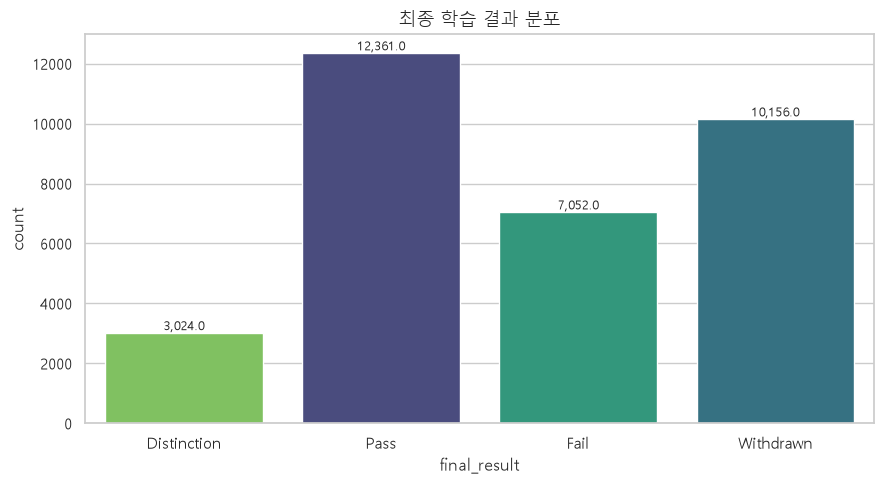

In [63]:
order = ["Distinction", "Pass", "Fail", "Withdrawn"]
ax = sns.countplot(data=info, x="final_result", order=order,
                   hue="final_result", palette="viridis", legend=False)
ax.set_title("최종 학습 결과 분포")
for p in ax.patches:
    ax.annotate(f"{p.get_height():,}", (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()


In [64]:
# 성공(Pass/Distinction) vs 미성공(Fail/Withdrawn) 이진 파생
info["success"] = info["final_result"].isin(["Pass", "Distinction"]).astype(int)
info["success"].value_counts(normalize=True).round(3)


success
0    0.528
1    0.472
Name: proportion, dtype: float64

## 3. 인구통계별 결과 차이

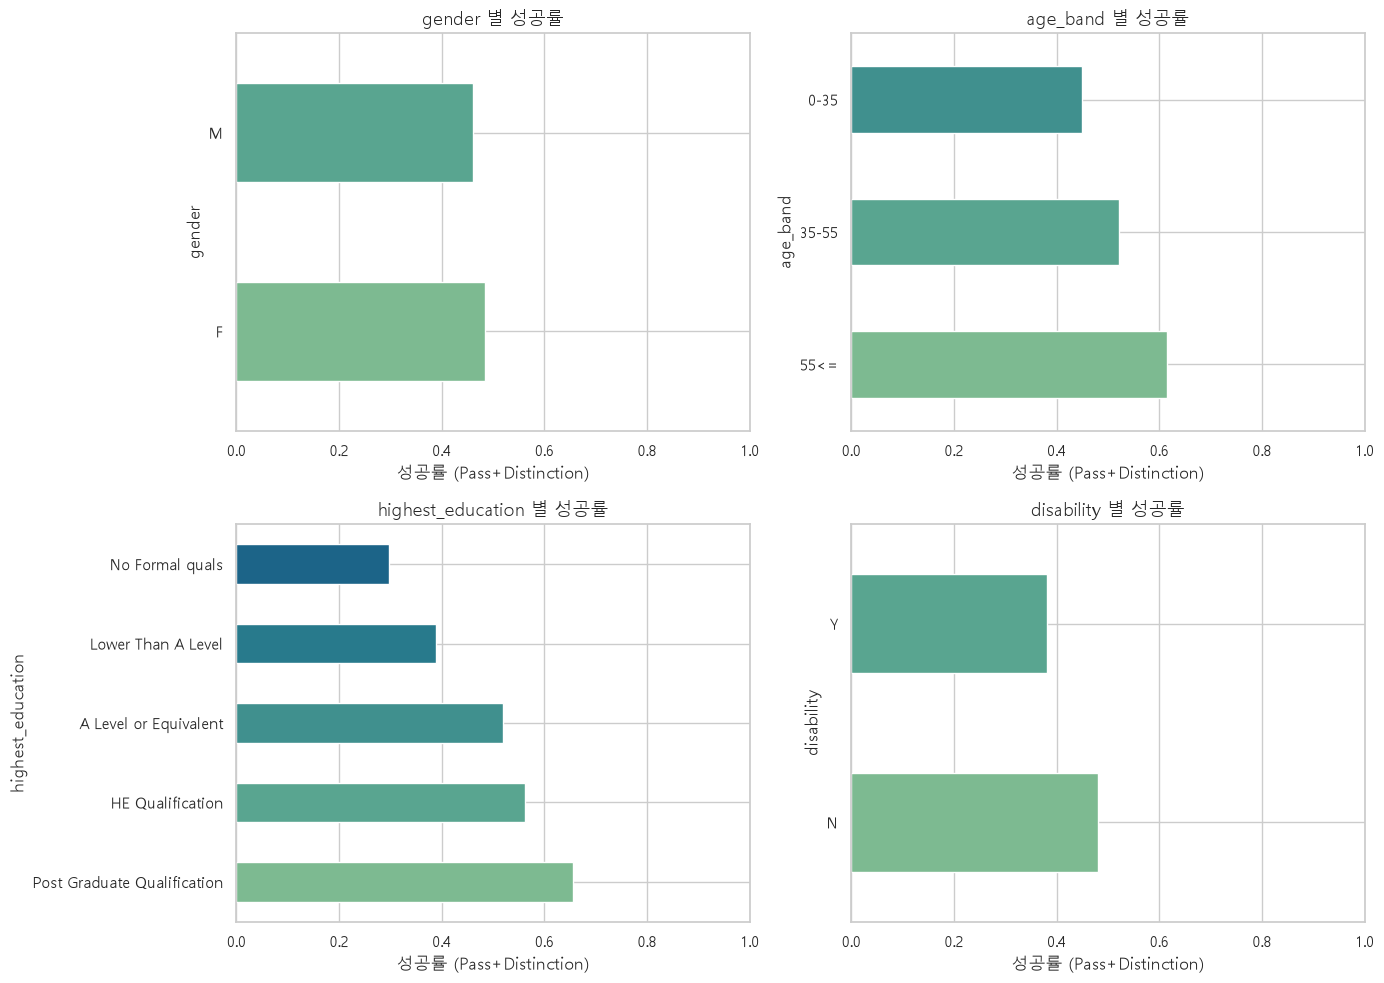

In [65]:
def rate_by(col, data=info, target="success"):
    g = data.groupby(col)[target].mean().sort_values(ascending=False)
    return g

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.ravel(), ["gender", "age_band", "highest_education", "disability"]):
    rate_by(col).plot(kind="barh", ax=ax, color=sns.color_palette("crest"))
    ax.set_title(f"{col} 별 성공률")
    ax.set_xlabel("성공률 (Pass+Distinction)")
    ax.set_xlim(0, 1)
plt.tight_layout(); plt.show()


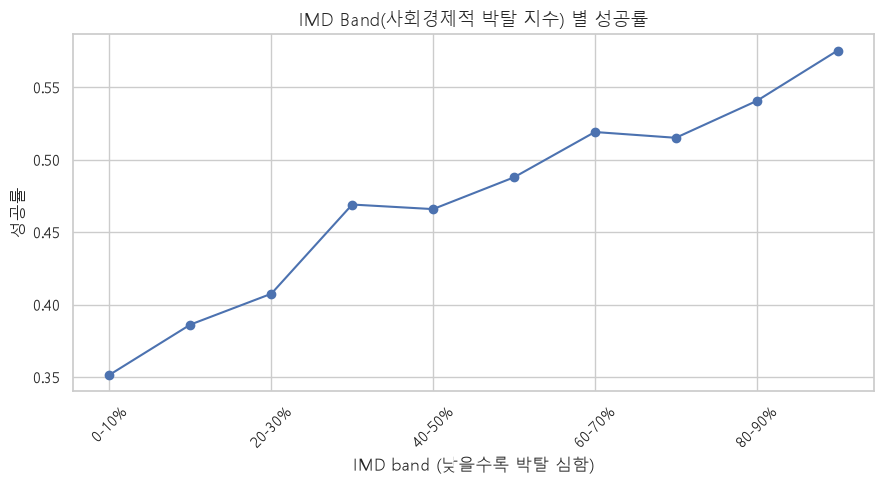

In [66]:
# IMD band (사회경제적 박탈 지수) — 순서 정렬
# 주의: 원본 데이터에 "10-20" 값이 "%" 없이 들어와 있어 정규화 후 정렬한다.
imd_order = ["0-10%", "10-20%", "20-30%", "30-40%", "40-50%",
             "50-60%", "60-70%", "70-80%", "80-90%", "90-100%"]
imd = info.dropna(subset=["imd_band"]).copy()
imd["imd_band"] = imd["imd_band"].replace({"10-20": "10-20%"})
imd["imd_band"] = pd.Categorical(imd["imd_band"], categories=imd_order, ordered=True)
g = imd.groupby("imd_band", observed=True)["success"].mean()

ax = g.plot(marker="o")
ax.set_title("IMD Band(사회경제적 박탈 지수) 별 성공률")
ax.set_ylabel("성공률"); ax.set_xlabel("IMD band (낮을수록 박탈 심함)")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

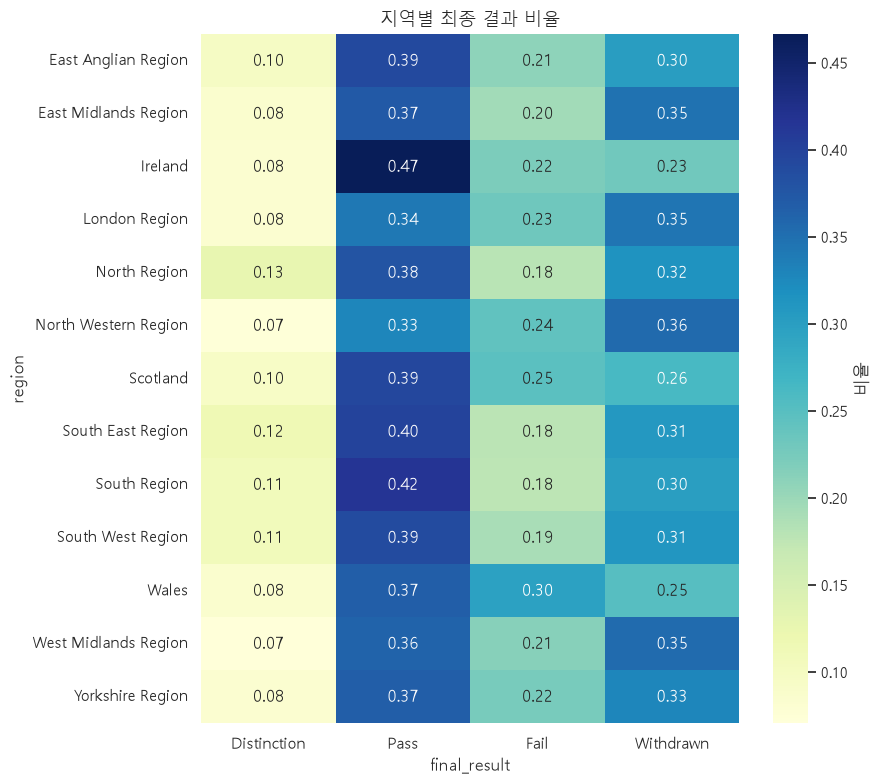

In [67]:
# final_result x region 교차 히트맵 (비율)
ct = pd.crosstab(info["region"], info["final_result"], normalize="index")[order]
plt.figure(figsize=(9, 8))
sns.heatmap(ct, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={"label": "비율"})
plt.title("지역별 최종 결과 비율")
plt.tight_layout(); plt.show()


## 4. 수치형 변수: 이전 시도 횟수 & 수강 학점

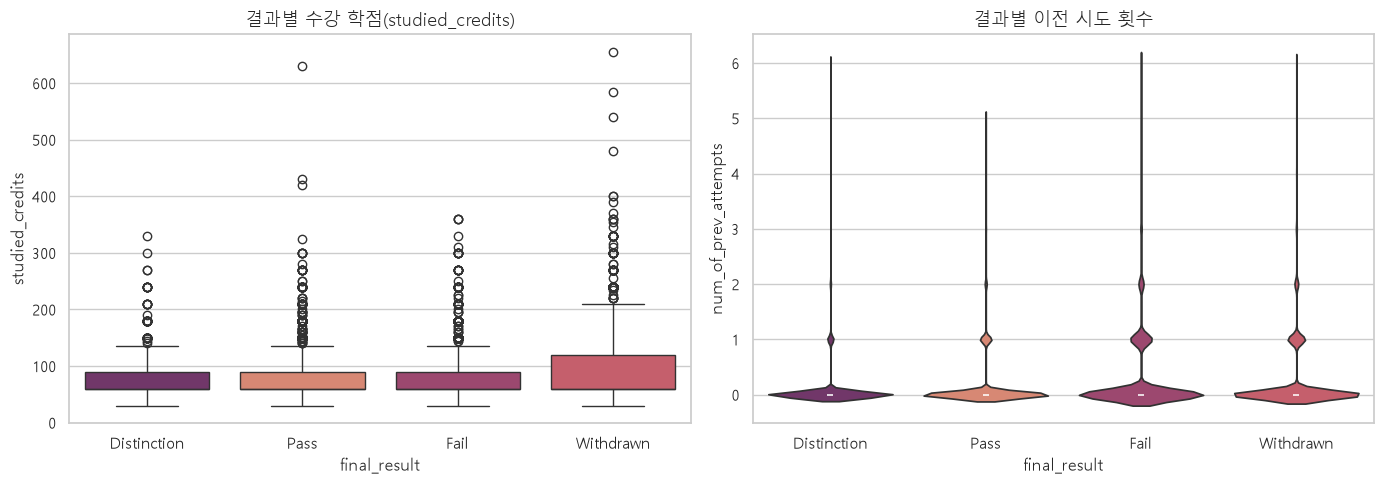

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=info, x="final_result", y="studied_credits",
            order=order, ax=axes[0], hue="final_result", palette="flare", legend=False)
axes[0].set_title("결과별 수강 학점(studied_credits)")

sns.violinplot(data=info, x="final_result", y="num_of_prev_attempts",
               order=order, ax=axes[1], hue="final_result", palette="flare", legend=False)
axes[1].set_title("결과별 이전 시도 횟수")
plt.tight_layout(); plt.show()


In [69]:
print(info.groupby("final_result")[["studied_credits", "num_of_prev_attempts"]]
      .agg(["mean", "median"]).round(2))


             studied_credits        num_of_prev_attempts       
                        mean median                 mean median
final_result                                                   
Distinction            71.76   60.0                 0.06    0.0
Fail                   76.09   60.0                 0.25    0.0
Pass                   74.22   60.0                 0.12    0.0
Withdrawn              91.43   60.0                 0.19    0.0


## 5. 모듈(과목)별 결과 & 등록 시점

In [70]:
reg = pd.read_csv(DATA / "studentRegistration.csv")
courses = pd.read_csv(DATA / "courses.csv")
print(reg.shape, courses.shape)
reg.head()


(32593, 5) (22, 3)


,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159.0,NaN
1,AAA,2013J,28400,-53.0,NaN
2,AAA,2013J,30268,-92.0,12.0
3,AAA,2013J,31604,-52.0,NaN
4,AAA,2013J,32885,-176.0,NaN


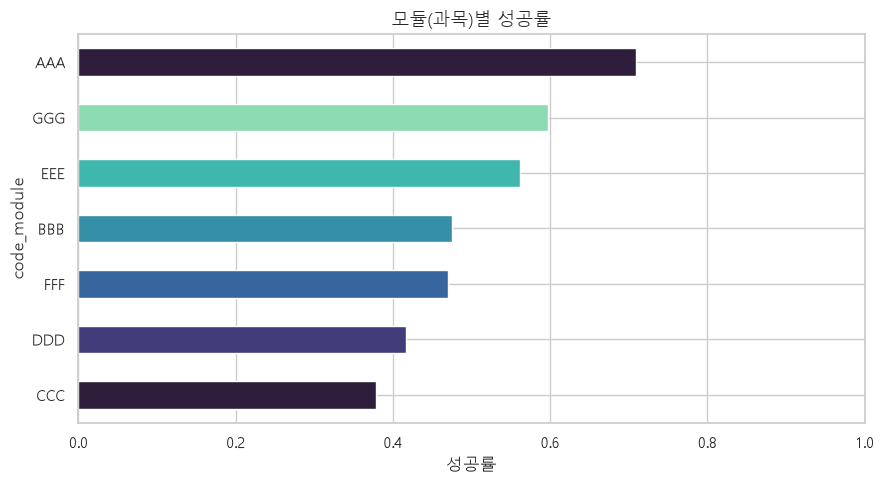

,mean,count
code_module,,
CCC,0.378439,4434
DDD,0.416135,6272
FFF,0.469982,7762
BBB,0.474649,7909
EEE,0.562372,2934
GGG,0.597474,2534
AAA,0.709893,748


In [71]:
# 모듈별 성공률
mod = info.groupby("code_module")["success"].agg(["mean", "count"]).sort_values("mean")
ax = mod["mean"].plot(kind="barh", color=sns.color_palette("mako"))
ax.set_title("모듈(과목)별 성공률")
ax.set_xlabel("성공률"); ax.set_xlim(0, 1)
plt.tight_layout(); plt.show()
mod


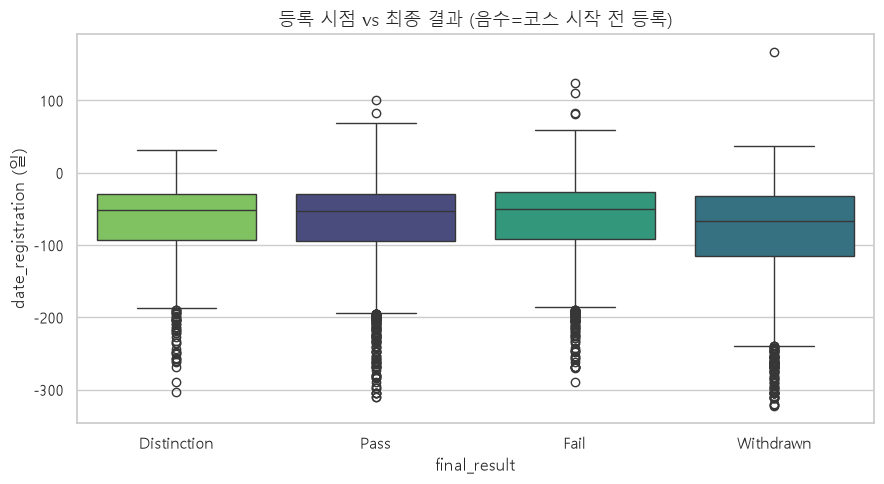

In [72]:
# 등록 시점(date_registration, 코스 시작 대비 일수)과 결과의 관계
m = info.merge(reg, on=["code_module", "code_presentation", "id_student"], how="left")
m_valid = m.dropna(subset=["date_registration"])
sns.boxplot(data=m_valid, x="final_result", y="date_registration", order=order,
            hue="final_result", palette="viridis", legend=False)
plt.title("등록 시점 vs 최종 결과 (음수=코스 시작 전 등록)")
plt.ylabel("date_registration (일)")
plt.tight_layout(); plt.show()


## 6. 평가 점수(studentAssessment) 요약

In [73]:
sa = pd.read_csv(DATA / "studentAssessment.csv")
assess = pd.read_csv(DATA / "assessments.csv")
print(sa.shape, assess.shape)
sa.describe()


(173912, 5) (206, 6)


,id_assessment,id_student,date_submitted,is_banked,score
count,173912.000000,1.739120e+05,173912.000000,173912.000000,173739.000000
mean,26553.803556,7.051507e+05,116.032942,0.010977,75.799573
std,8829.784254,5.523952e+05,71.484148,0.104194,18.798107
min,1752.000000,6.516000e+03,-11.000000,0.000000,0.000000
25%,15022.000000,5.044290e+05,51.000000,0.000000,65.000000
50%,25359.000000,5.852080e+05,116.000000,0.000000,80.000000
75%,34883.000000,6.344980e+05,173.000000,0.000000,90.000000
max,37443.000000,2.698588e+06,608.000000,1.000000,100.000000


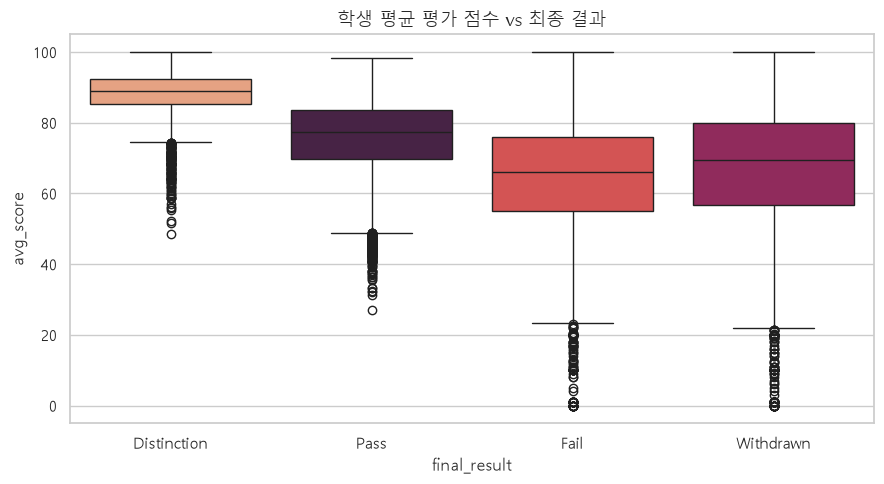

In [74]:
# 학생별 평균 평가 점수 → 최종 결과와 연결
stu_score = sa.groupby("id_student")["score"].mean().rename("avg_score")
info2 = info.merge(stu_score, on="id_student", how="left")

sns.boxplot(data=info2, x="final_result", y="avg_score", order=order,
            hue="final_result", palette="rocket", legend=False)
plt.title("학생 평균 평가 점수 vs 최종 결과")
plt.tight_layout(); plt.show()


## 7. 요약

- **타깃 불균형:** Withdrawn 비율이 상당해 이진 성공 분류 시 클래스 불균형 고려 필요.
- **인구통계 신호:** IMD band(사회경제 지수)와 highest_education에서 성공률 gradient가 뚜렷.
- **행동 신호:** 평균 평가 점수·등록 시점이 결과와 강하게 연관 → 예측 모델의 핵심 피처 후보.
- **다음 단계:** VLE 클릭 로그(노트북 2)로 **온라인 참여도** 피처를 추가해 조기 이탈/실패 예측으로 확장.
